<a href="https://colab.research.google.com/github/nauerromero/Ciencia_de_Datos_II/blob/main/CasoPractico1_Punto1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pasos del SVM al dataset de 'Cancer de Mamas' :https://media.geeksforgeeks.org/wp-content/uploads/20250516142928101881/data-.csv

SVM - Fit regression model : SVR

🔹 SVR-RBF MSE: 0.0617
🔹 SVR-RBF R²: 73.72%
🔹 SVR-Linear MSE: 0.0717
🔹 SVR-Linear R²: 69.47%
🔹 SVR-Polynomial MSE: 0.3901
🔹 SVR-Polynomial R²: -66.06%


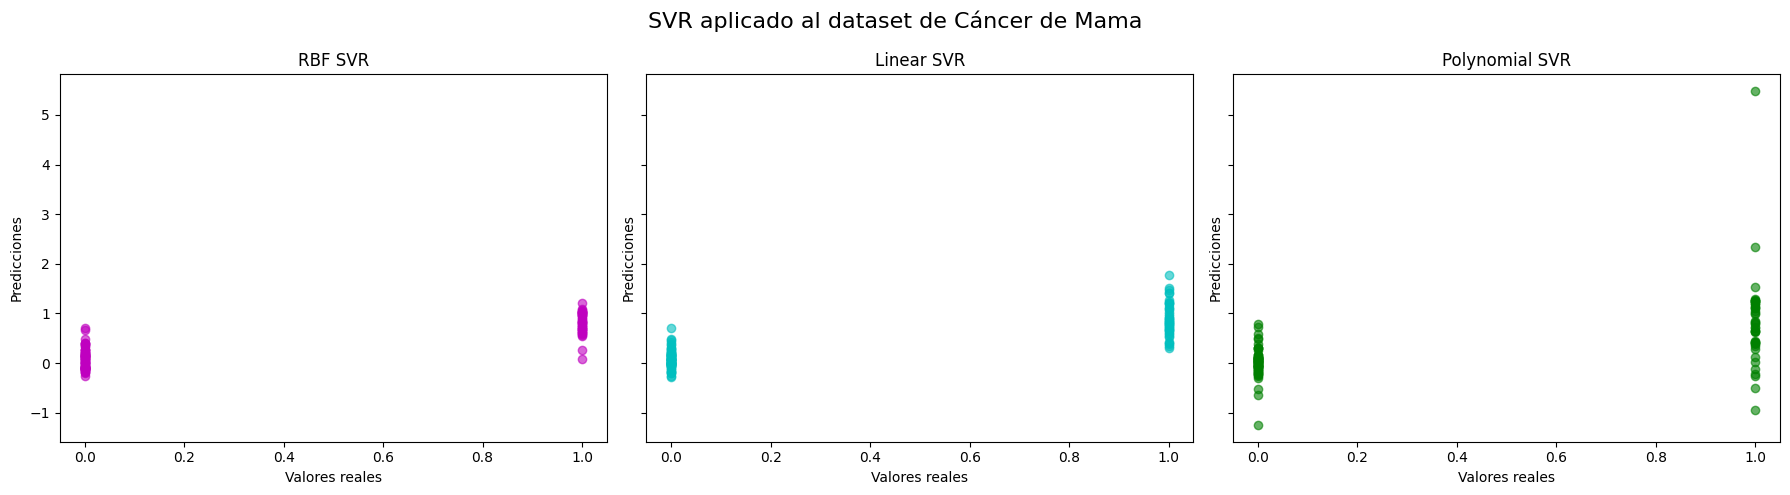

In [ ]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#Cargar el dataset desde GeeksforGeeks
url = "https://media.geeksforgeeks.org/wp-content/uploads/20250516142928101881/data-.csv"
df = pd.read_csv(url)

#Limpieza estructural
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")  # Eliminar columnas irrelevantes si existen

#Codificar variable objetivo
y = df["diagnosis"].map({"M": 1, "B": 0})  # Maligno = 1, Benigno = 0
X = df.drop(columns=["diagnosis"])        # El resto son features

#Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#División de datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Definir modelos SVR
svrs = [
    SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1),
    SVR(kernel="linear", C=100, gamma="auto"),
    SVR(kernel="poly", C=100, gamma="auto", degree=3, epsilon=0.1, coef0=1)
]
kernel_label = ["RBF", "Linear", "Polynomial"]
model_color = ["m", "c", "g"]

#Entrenamiento y visualización
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharey=True)
for ix, svr in enumerate(svrs):
    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)

    axes[ix].scatter(y_test, y_pred, color=model_color[ix], alpha=0.6)
    axes[ix].set_title(f"{kernel_label[ix]} SVR")
    axes[ix].set_xlabel("Valores reales")
    axes[ix].set_ylabel("Predicciones")

    print(f"🔹 SVR-{kernel_label[ix]} MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"🔹 SVR-{kernel_label[ix]} R²: {r2_score(y_test, y_pred)*100:.2f}%")

fig.suptitle("SVR aplicado al dataset de Cáncer de Mama", fontsize=16)
plt.tight_layout()
plt.show()